This notebook is the original work of Vikrant Singh [ vikrant_s@ch.iitr.ac.in , 7088704043 ], created as part of the Socbiz Summer 2025 Open Project. It showcases a comprehensive approach to credit risk modeling, including data exploration, feature engineering, and predictive modeling for credit card default prediction. All analysis, code, and insights presented here are my own.

For any queries or issue ,Please feel free to Contact.

In [ ]:
import pandas as pd
import numpy as np
import calendar
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
data=pd.read_csv('Airline_Delay_Cause.csv')

# Description

In [ ]:
data.shape

(179338, 21)

In [ ]:
data.sample(10)

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
31577,2022,8,OO,SkyWest Airlines Inc.,TYS,"Knoxville, TN: McGhee Tyson",101.0,27.0,12.00,2.00,...,1.00,11.00,4.0,0.0,2072.0,910.0,83.0,178.0,36.0,865.0
162596,2016,4,OO,SkyWest Airlines Inc.,MFE,"Mission/McAllen/Edinburg, TX: McAllen Miller I...",1.0,0.0,0.00,0.00,...,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
21500,2023,1,G7,GoJet Airlines LLC d/b/a United Express,CID,"Cedar Rapids/Iowa City, IA: The Eastern Iowa",27.0,9.0,3.53,0.00,...,0.00,1.79,0.0,0.0,417.0,204.0,0.0,129.0,0.0,84.0
94541,2019,11,YX,Republic Airline,JAX,"Jacksonville, FL: Jacksonville International",289.0,30.0,6.58,0.00,...,0.00,16.27,0.0,0.0,1370.0,236.0,0.0,295.0,0.0,839.0
28957,2022,9,G4,Allegiant Air,AUS,"Austin, TX: Austin - Bergstrom International",88.0,20.0,7.14,0.00,...,0.00,9.30,0.0,0.0,1074.0,431.0,0.0,147.0,0.0,496.0
17160,2023,3,AS,Alaska Airlines Network,LAX,"Los Angeles, CA: Los Angeles International",771.0,227.0,53.90,0.86,...,1.97,76.66,8.0,4.0,12248.0,3851.0,33.0,3262.0,61.0,5041.0
159662,2016,7,VX,Virgin America,SAN,"San Diego, CA: San Diego International",164.0,32.0,5.76,0.00,...,0.00,24.60,1.0,0.0,1930.0,303.0,0.0,63.0,0.0,1564.0
172385,2015,6,AA,American Airlines Inc.,MCO,"Orlando, FL: Orlando International",836.0,202.0,76.00,9.92,...,0.00,60.88,5.0,7.0,12547.0,4403.0,709.0,2639.0,0.0,4796.0
150172,2017,4,OO,SkyWest Airlines Inc.,DHN,"Dothan, AL: Dothan Regional",25.0,1.0,0.10,0.00,...,0.00,0.90,2.0,0.0,264.0,27.0,0.0,0.0,0.0,237.0
168406,2015,10,EV,ExpressJet Airlines Inc.,ICT,"Wichita, KS: Wichita Dwight D Eisenhower National",203.0,19.0,5.95,0.00,...,0.00,5.23,5.0,1.0,812.0,314.0,0.0,210.0,0.0,288.0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179338 entries, 0 to 179337
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 179338 non-null  int64  
 1   month                179338 non-null  int64  
 2   carrier              179338 non-null  object 
 3   carrier_name         179338 non-null  object 
 4   airport              179338 non-null  object 
 5   airport_name         179338 non-null  object 
 6   arr_flights          178997 non-null  float64
 7   arr_del15            178747 non-null  float64
 8   carrier_ct           178997 non-null  float64
 9   weather_ct           178997 non-null  float64
 10  nas_ct               178997 non-null  float64
 11  security_ct          178997 non-null  float64
 12  late_aircraft_ct     178997 non-null  float64
 13  arr_cancelled        178997 non-null  float64
 14  arr_diverted         178997 non-null  float64
 15  arr_delay        

In [ ]:
data.isnull().mean()*100

,0
year,0.000000
month,0.000000
carrier,0.000000
carrier_name,0.000000
airport,0.000000
airport_name,0.000000
arr_flights,0.190144
arr_del15,0.329545
carrier_ct,0.190144
weather_ct,0.190144


In [ ]:
cols1 =[var for var in data.columns if data[var].isnull().mean()*100 <5]
print(cols1)

['year', 'month', 'carrier', 'carrier_name', 'airport', 'airport_name', 'arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted', 'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']


In [ ]:
cols2 =[var for var in data.columns if data[var].isnull().mean()*100>5]
print(cols2)

[]


In [ ]:
df=data.copy()
df.describe()

,year,month,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
count,179338.000000,179338.000000,178997.000000,178747.000000,178997.000000,178997.000000,178997.000000,178997.000000,178997.000000,178997.000000,178997.000000,178997.000000,178997.000000,178997.000000,178997.000000,178997.000000,178997.000000
mean,2019.480082,6.485725,327.816969,58.709086,18.572643,2.035742,17.094929,0.145307,20.778477,6.830103,0.779572,3863.310676,1325.546199,209.113426,819.949284,6.839941,1501.854875
std,2.410204,3.463516,931.001446,164.378035,47.389651,6.894812,56.279604,0.702149,64.912766,41.446756,3.490499,11902.153241,4067.786987,791.817638,3178.603458,40.440497,4878.178427
min,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2018.000000,3.000000,41.000000,6.000000,1.960000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,288.000000,91.000000,0.000000,28.000000,0.000000,54.000000
50%,2020.000000,6.000000,89.000000,15.000000,5.400000,0.220000,3.300000,0.000000,4.290000,1.000000,0.000000,900.000000,321.000000,12.000000,124.000000,0.000000,286.000000
75%,2022.000000,9.000000,218.000000,40.000000,14.700000,1.620000,9.860000,0.000000,13.010000,3.000000,1.000000,2547.000000,986.000000,131.000000,401.000000,0.000000,964.000000
max,2023.000000,12.000000,21977.000000,4176.000000,1293.910000,266.420000,1884.420000,58.690000,2069.070000,4951.000000,160.000000,438783.000000,196944.000000,31960.000000,112018.000000,3760.000000,227959.000000


In [ ]:
df.duplicated().sum()

np.int64(0)

# Exploratory Data Analysis
Analayzing each column of the Data set to gain insight from the data and construct some new features

## 1.Year

Yearly Total No of Flights

Text(0.5, 1.0, 'Value Count vs Year')

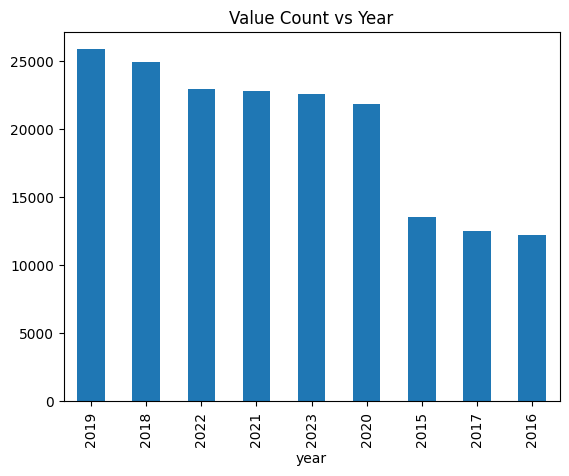

In [ ]:
df['year'].value_counts().plot(kind='bar')
plt.title('Value Count vs Year')


In [ ]:
df.groupby('year')['arr_flights'].sum().reset_index()

,year,arr_flights
0,2015,5819079.0
1,2016,5617658.0
2,2017,5674621.0
3,2018,7848697.0
4,2019,8091684.0
5,2020,5022397.0
6,2021,6311871.0
7,2022,7013508.0
8,2023,7278739.0


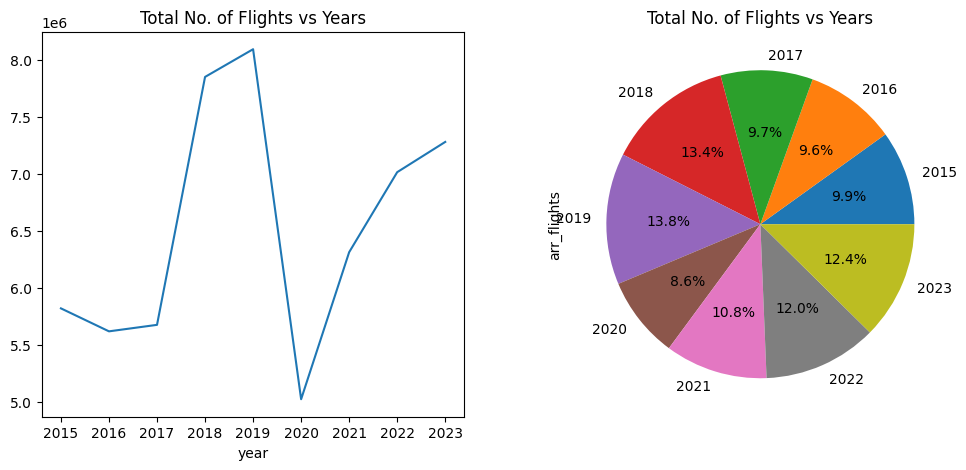

In [ ]:
fig,axes =plt.subplots(1,2,figsize=(12,5))
df.groupby('year')['arr_flights'].sum().plot(kind='line',ax=axes[0])
axes[0].set_title('Total No. of Flights vs Years')
plt.ticklabel_format(style='plain', axis='y')
df.groupby('year')['arr_flights'].sum().plot(kind='pie',autopct='%.1f%%',ax=axes[1])
axes[1].set_title('Total No. of Flights vs Years')
plt.ticklabel_format(style='plain', axis='y')

Yearly Average Delay in Minutes

In [ ]:
df.groupby('year')['arr_delay'].mean().reset_index()

,year,arr_delay
0,2015,4635.385247
1,2016,4906.571569
2,2017,5261.966901
3,2018,3898.752086
4,2019,4121.367895
5,2020,1349.491419
6,2021,3139.897202
7,2022,4210.782455
8,2023,4524.578232


Delay Trend over Years

Text(0.5, 1.0, 'Average Delay  vs Years')

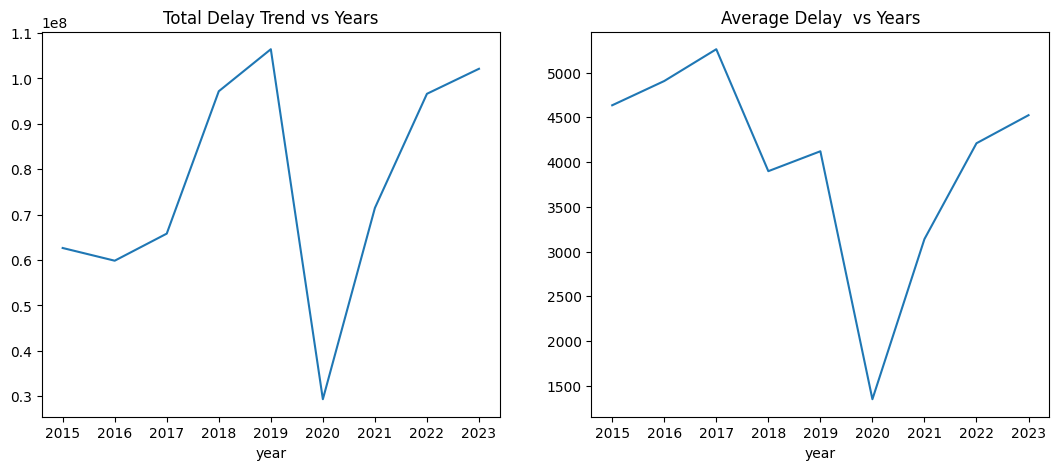

In [ ]:
figure,axes =plt.subplots(1,2,figsize=(13,5))
df.groupby('year')['arr_delay'].sum().plot(kind='line',ax=axes[0])
axes[0].set_title('Total Delay Trend vs Years')
plt.ticklabel_format(style='plain', axis='y')
df.groupby('year')['arr_delay'].mean().plot(kind='line',ax=axes[1])
axes[1].set_title('Average Delay  vs Years')

## 2.Month

In [ ]:
df['month'].value_counts()

,count
month,
1,15259
3,15220
12,15111
2,14982
6,14962
4,14913
9,14891
8,14889
11,14854


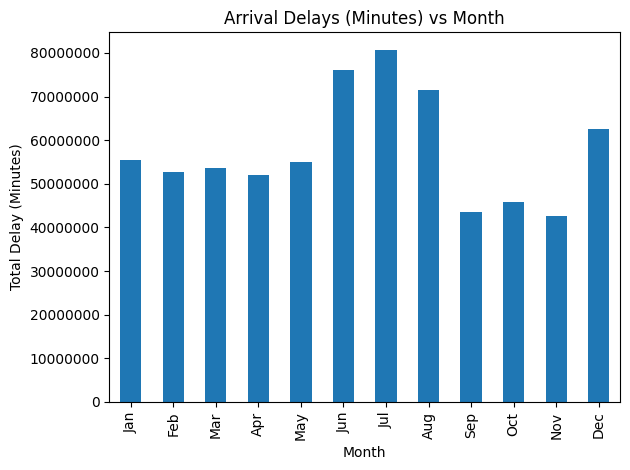

In [ ]:
monthly_delay = df.groupby('month')['arr_delay'].sum()
monthly_delay.index = monthly_delay.index.map(lambda x: calendar.month_abbr[x])
monthly_delay.plot(kind='bar')
plt.ticklabel_format(style='plain', axis='y')
plt.title('Arrival Delays (Minutes) vs Month')
plt.xlabel('Month')
plt.ylabel('Total Delay (Minutes)')
plt.tight_layout()
plt.show()

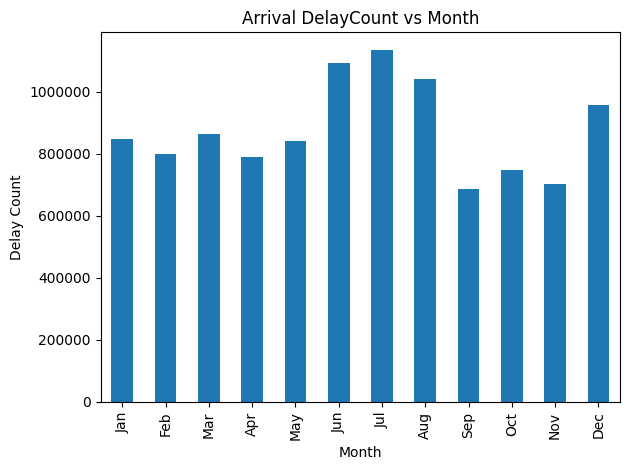

In [ ]:
monthly_delay = df.groupby('month')['arr_del15'].sum()
monthly_delay.index = monthly_delay.index.map(lambda x: calendar.month_abbr[x])
monthly_delay.plot(kind='bar')
plt.ticklabel_format(style='plain', axis='y')
plt.title('Arrival DelayCount vs Month')
plt.xlabel('Month')
plt.ylabel('Delay Count')
plt.tight_layout()
plt.show()

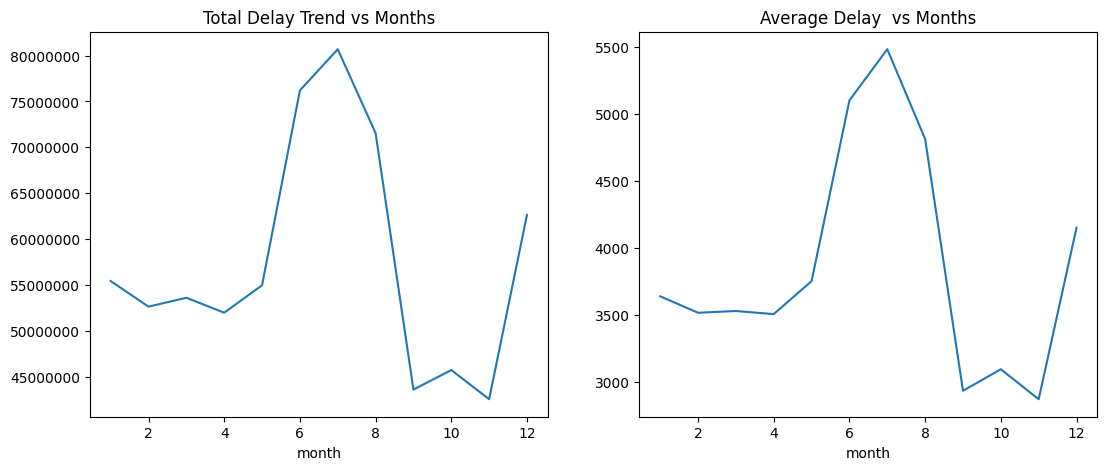

In [ ]:
figure,axes =plt.subplots(1,2,figsize=(13,5))

df.groupby('month')['arr_delay'].sum().plot(kind='line',ax=axes[0])
axes[0].ticklabel_format(style='plain', axis='y')
axes[0].set_title('Total Delay Trend vs Months')

df.groupby('month')['arr_delay'].mean().plot(kind='line',ax=axes[1])
axes[1].set_title('Average Delay  vs Months')
axes[1].ticklabel_format(style='plain', axis='y')

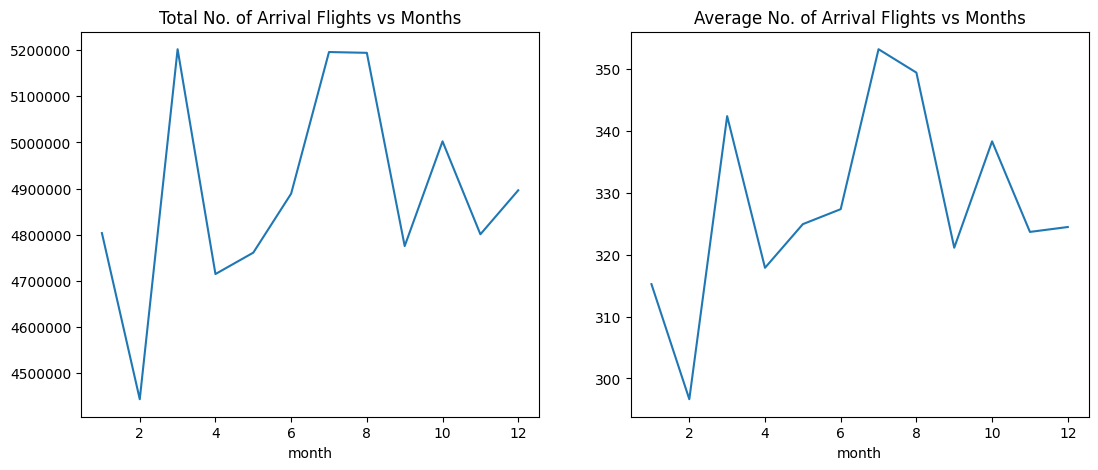

In [ ]:
figure,axes =plt.subplots(1,2,figsize=(13,5))

df.groupby('month')['arr_flights'].sum().plot(kind='line',ax=axes[0])
axes[0].ticklabel_format(style='plain', axis='y')
axes[0].set_title('Total No. of Arrival Flights vs Months')

df.groupby('month')['arr_flights'].mean().plot(kind='line',ax=axes[1])
axes[1].set_title('Average No. of Arrival Flights vs Months')
axes[1].ticklabel_format(style='plain', axis='y')

## 3.Carrier

Text(0.5, 1.0, 'Value Count vs Carrier ')

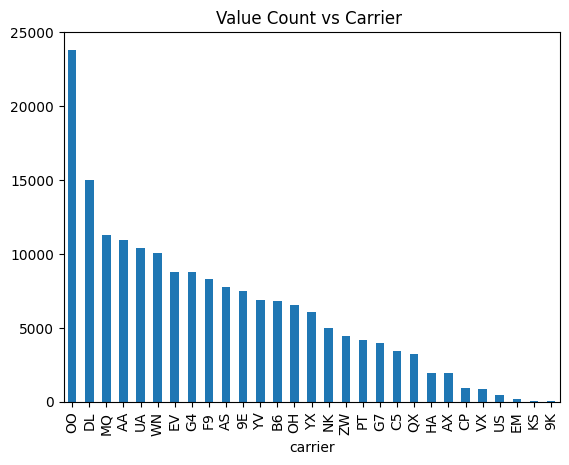

In [ ]:
df['carrier'].value_counts().plot(kind='bar')
plt.title('Value Count vs Carrier ')

In [ ]:
df.groupby('airport')['arr_delay'].mean().sort_values(ascending=False).head(10)

,arr_delay
airport,
ORD,26264.231025
DFW,25774.706897
ATL,21681.522293
DEN,21058.615686
JFK,18694.831962
SFO,18284.369176
SFB,16881.680556
LAX,16790.225882
EWR,16693.612654


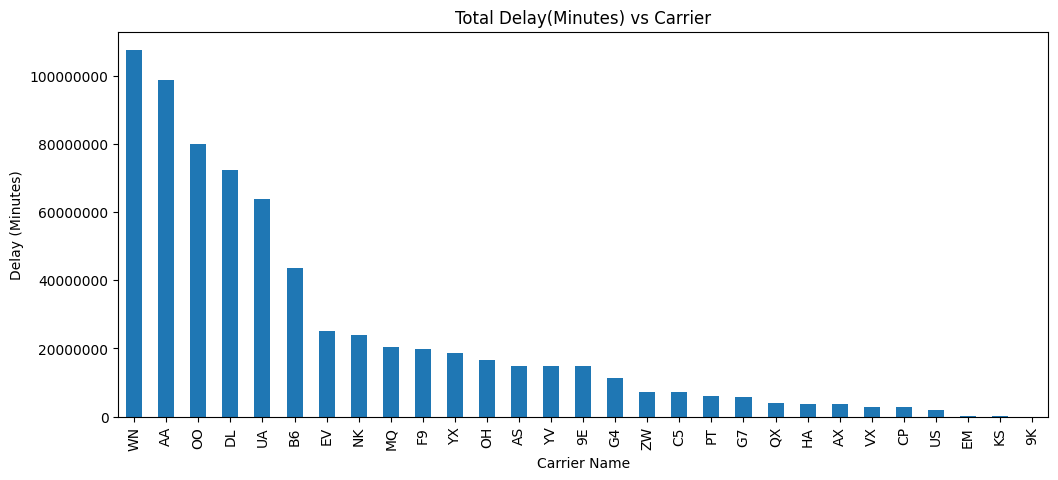

In [ ]:
plt.figure(figsize=(12,5))
df.groupby('carrier')['arr_delay'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Total Delay(Minutes) vs Carrier')
plt.xlabel('Carrier Name')
plt.ylabel('Delay (Minutes)')
plt.ticklabel_format(style='plain',axis='y')

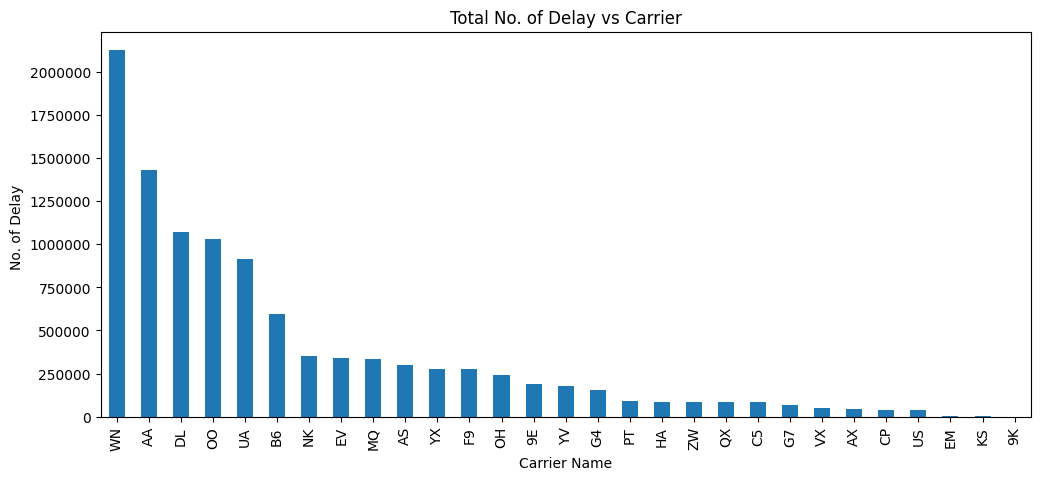

In [ ]:
plt.figure(figsize=(12,5))
df.groupby('carrier')['arr_del15'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Total No. of Delay vs Carrier')
plt.xlabel('Carrier Name')
plt.ylabel('No. of Delay ')
plt.ticklabel_format(style='plain',axis='y')

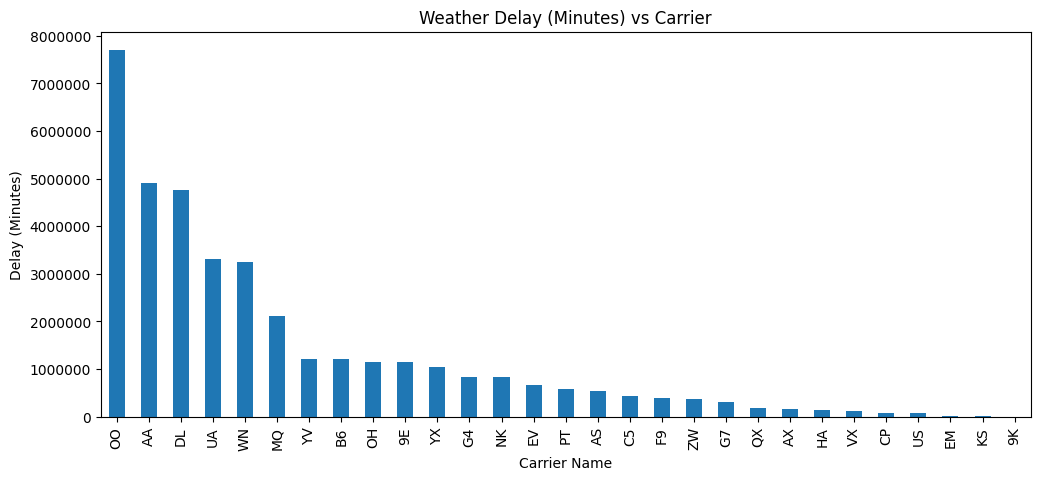

In [ ]:
plt.figure(figsize=(12,5))
df.groupby('carrier')['weather_delay'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Weather Delay (Minutes) vs Carrier')
plt.xlabel('Carrier Name')
plt.ylabel('Delay (Minutes)')
plt.ticklabel_format(style='plain',axis='y')

# 4.Airport

In [ ]:
df['airport'].value_counts().reset_index()

,airport,count
0,CLE,1593
1,DTW,1580
2,BNA,1550
3,PIT,1536
4,IND,1533
...,...,...
391,YNG,1
392,TKI,1
393,FNL,1
394,EFD,1


In [ ]:
df.groupby('airport')[[
    'carrier_delay',
    'weather_delay',
    'nas_delay',
    'security_delay',
    'late_aircraft_delay'
]].sum().head(20)

,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
airport,,,,,
ABE,174642.0,42530.0,66883.0,820.0,173273.0
ABI,38653.0,19096.0,22836.0,293.0,46256.0
ABQ,759851.0,84419.0,220373.0,3575.0,915894.0
ABR,27971.0,17389.0,4286.0,0.0,10045.0
ABY,40515.0,10277.0,9998.0,14.0,22250.0
ACK,59894.0,28348.0,25474.0,112.0,59818.0
ACT,46432.0,8961.0,13824.0,281.0,41856.0
ACV,83623.0,37603.0,16194.0,0.0,78261.0
ACY,92007.0,15464.0,169048.0,2986.0,129565.0


In [ ]:
df.groupby('airport')['arr_delay'].sum().sort_values(ascending=False).head(10).reset_index()

,airport,arr_delay
0,ORD,39448875.0
1,DFW,32888526.0
2,ATL,30635991.0
3,DEN,26849735.0
4,EWR,21634922.0
5,LAX,21407538.0
6,SFO,20405356.0
7,LGA,18129309.0
8,CLT,17972636.0
9,MCO,16625359.0


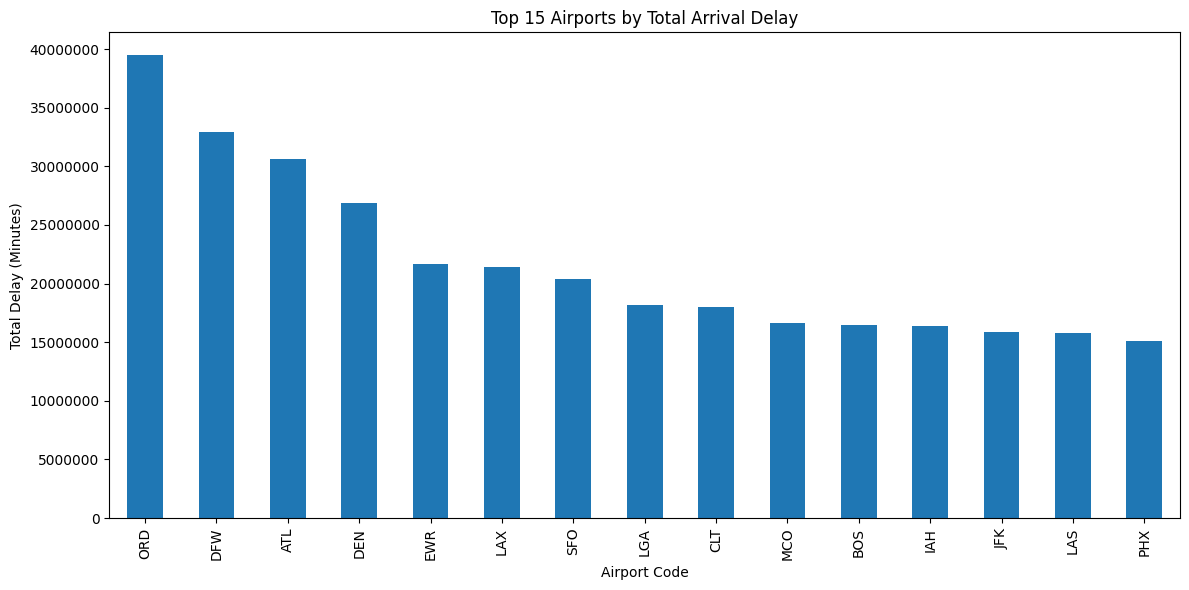

In [ ]:
top_airports = df.groupby('airport')['arr_delay'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
top_airports.plot(kind='bar')
plt.title('Top 15 Airports by Total Arrival Delay')
plt.xlabel('Airport Code')
plt.ylabel('Total Delay (Minutes)')
plt.ticklabel_format(style='plain',axis='y')
plt.tight_layout()
plt.show()



# Other Insights

In [ ]:
cancel_rate = df.groupby('airport')['arr_cancelled'].sum() / df.groupby('airport')['arr_flights'].sum()
cancel_rate.head(20).reset_index()

,airport,0
0,ABE,0.028400
1,ABI,0.026228
2,ABQ,0.015494
3,ABR,0.016505
4,ABY,0.007683
5,ACK,0.038629
6,ACT,0.036730
7,ACV,0.039521
8,ACY,0.023167
9,ADK,0.059638


In [ ]:
divert_rate = df.groupby('airport')['arr_diverted'].sum() / df.groupby('airport')['arr_flights'].sum()
divert_rate.head(20).reset_index()

,airport,0
0,ABE,0.002458
1,ABI,0.001665
2,ABQ,0.001367
3,ABR,0.004240
4,ABY,0.003659
5,ACK,0.007798
6,ACT,0.001125
7,ACV,0.009703
8,ACY,0.001491
9,ADK,0.004260


In [ ]:
df['delay_status']=df['arr_delay'].map(lambda x:1 if x>15 else 0)

<Axes: xlabel='delay_status'>

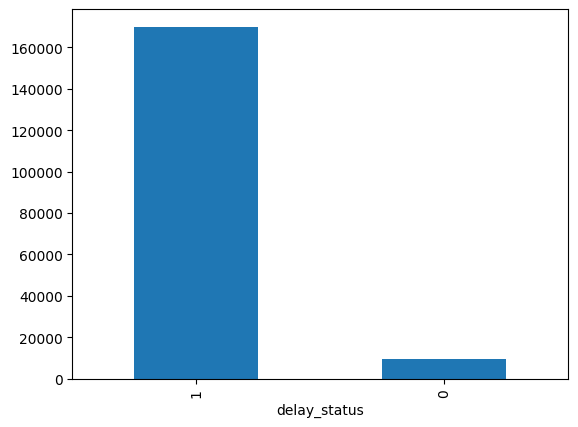

In [ ]:
df['delay_status'].value_counts().plot(kind='bar')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179338 entries, 0 to 179337
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 179338 non-null  int64  
 1   month                179338 non-null  int64  
 2   carrier              179338 non-null  object 
 3   carrier_name         179338 non-null  object 
 4   airport              179338 non-null  object 
 5   airport_name         179338 non-null  object 
 6   arr_flights          178997 non-null  float64
 7   arr_del15            178747 non-null  float64
 8   carrier_ct           178997 non-null  float64
 9   weather_ct           178997 non-null  float64
 10  nas_ct               178997 non-null  float64
 11  security_ct          178997 non-null  float64
 12  late_aircraft_ct     178997 non-null  float64
 13  arr_cancelled        178997 non-null  float64
 14  arr_diverted         178997 non-null  float64
 15  arr_delay        

In [ ]:

required_cols = ['arr_flights','arr_del15',
                 'carrier_ct','weather_ct','nas_ct','security_ct','late_aircraft_ct','arr_cancelled',
                 'arr_diverted','arr_delay','carrier_delay','weather_delay','nas_delay','security_delay',
                 'late_aircraft_delay','delay_status']

cor=df[required_cols].corr()

In [ ]:
for col in df.columns:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())



Column: year
year
2019    25858
2018    24956
2022    22964
2021    22800
2023    22621
2020    21876
2015    13528
2017    12518
2016    12217
Name: count, dtype: int64

Column: month
month
1     15259
3     15220
12    15111
2     14982
6     14962
4     14913
9     14891
8     14889
11    14854
10    14842
7     14739
5     14676
Name: count, dtype: int64

Column: carrier
carrier
OO    23821
DL    14980
MQ    11299
AA    10912
UA    10418
WN    10051
EV     8793
G4     8761
F9     8307
AS     7754
9E     7494
YV     6877
B6     6827
OH     6545
YX     6072
NK     4950
ZW     4468
PT     4160
G7     3948
C5     3430
QX     3203
HA     1952
AX     1932
CP      926
VX      821
US      434
EM      144
KS       44
9K       15
Name: count, dtype: int64

Column: carrier_name
carrier_name
SkyWest Airlines Inc.                        23821
Envoy Air                                    11299
Delta Air Lines Network                       9677
Allegiant Air                                 8761


<Axes: >

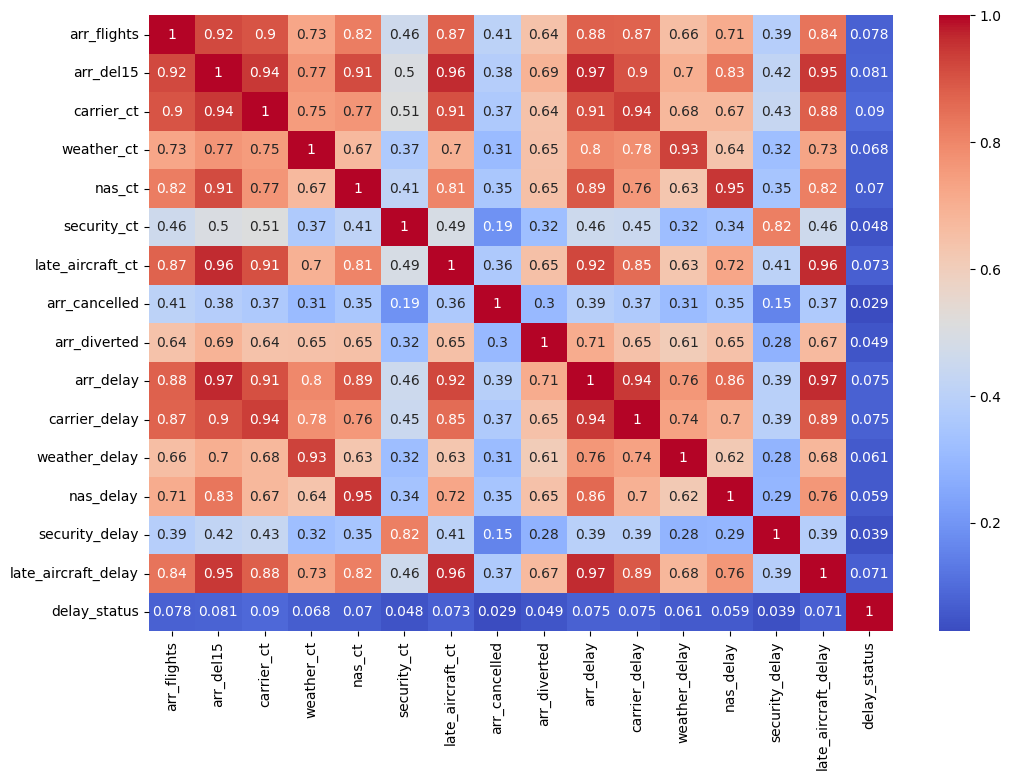

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(cor,annot=True,cmap='coolwarm')

# Feature Engineering

In [ ]:
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)


In [ ]:
df = df[df["arr_flights"] > 0]
df["arr_del15_rate"] = df["arr_del15"] / df["arr_flights"]
df["is_delayed"] = (df["arr_del15_rate"] > 0.05).astype(int)


<ipython-input-98-1814203812>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["arr_del15_rate"] = df["arr_del15"] / df["arr_flights"]
<ipython-input-98-1814203812>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["is_delayed"] = (df["arr_del15_rate"] > 0.05).astype(int)


In [ ]:
categorical = ["carrier", "airport"]
numeric = [
     "arr_flights","month_sin", "month_cos",
    "carrier_ct", "weather_ct", "nas_ct", "security_ct", "late_aircraft_ct"]


In [ ]:
x = df[numeric + list(categorical)]
y = df["is_delayed"]

In [ ]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 178997 entries, 0 to 179337
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   arr_flights       178997 non-null  float64
 1   month_sin         178997 non-null  float64
 2   month_cos         178997 non-null  float64
 3   carrier_ct        178997 non-null  float64
 4   weather_ct        178997 non-null  float64
 5   nas_ct            178997 non-null  float64
 6   security_ct       178997 non-null  float64
 7   late_aircraft_ct  178997 non-null  float64
 8   carrier           178997 non-null  object 
 9   airport           178997 non-null  object 
dtypes: float64(8), object(2)
memory usage: 15.0+ MB


# Dealing with Class Imbalance

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder


preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
         categorical)
    ]
)


In [ ]:
x_train_ct= preprocessor.fit_transform(x_train)
x_test_ct = preprocessor.transform(x_test)

In [ ]:
from imblearn.over_sampling import SMOTE
smote=SMOTE()

In [ ]:
x_train_sm,y_train_sm=smote.fit_resample(x_train_ct,y_train)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,f1_score,confusion_matrix,accuracy_score,ConfusionMatrixDisplay

In [ ]:
rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
)
rf.fit(x_train_sm,y_train_sm)

RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_leaf=3, n_estimators=300, n_jobs=-1,
                       random_state=42)

In [ ]:
y_pred=rf.predict(x_test_ct)
y_pred_train=rf.predict(x_train_sm)
print(classification_report(y_test,y_pred))
print(classification_report(y_train_sm,y_pred_train))

              precision    recall  f1-score   support

           0       0.53      0.86      0.66      4148
           1       0.99      0.92      0.95     40602

    accuracy                           0.92     44750
   macro avg       0.76      0.89      0.81     44750
weighted avg       0.94      0.92      0.93     44750

              precision    recall  f1-score   support

           0       0.92      0.94      0.93    121438
           1       0.94      0.92      0.93    121438

    accuracy                           0.93    242876
   macro avg       0.93      0.93      0.93    242876
weighted avg       0.93      0.93      0.93    242876



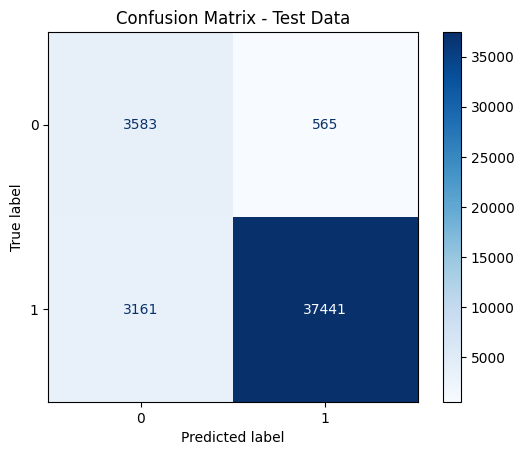

In [ ]:
cm_test = confusion_matrix(y_test, y_pred)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=rf.classes_)
disp_test.plot(cmap='Blues')
plt.title("Confusion Matrix - Test Data")
plt.show()

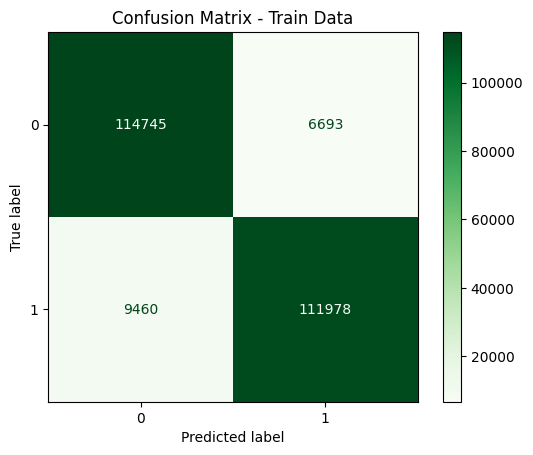

In [ ]:
cm_train = confusion_matrix(y_train_sm,y_pred_train)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=rf.classes_)
disp_train.plot(cmap='Greens')
plt.title("Confusion Matrix - Train Data")
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

In [ ]:
y_proba_test = rf.predict_proba(x_test_ct)[:, 1]

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba_test)
roc_auc = auc(fpr, tpr)

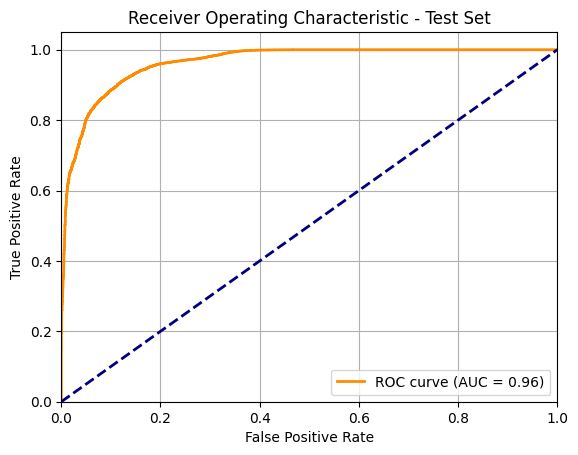

AUC Score (Test Set): 0.9637158510321303


In [ ]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Test Set')
plt.legend(loc="lower right")
plt.grid()
plt.show()

print("AUC Score (Test Set):", roc_auc)

# Feature Engineering for Regression

In [ ]:
from sklearn.metrics import r2_score

In [ ]:
df["month_sin"] = np.sin(2*np.pi*df["month"]/12)
df["month_cos"] = np.cos(2*np.pi*df["month"]/12)

In [ ]:
rate_cols_ct = ["carrier_ct","weather_ct","nas_ct","security_ct","late_aircraft_ct"]
for c in rate_cols_ct:
    df[f"{c}_rate"] = df[c]/df["arr_flights"]


In [ ]:
df["arr_del15_rate"] = df["arr_del15"] / df["arr_flights"]
df["avg_delay_per_flight"] = df["arr_delay"] / df["arr_flights"]


In [ ]:
categorical = ["carrier", "airport"]
numeric = [
    "month_sin","month_cos","arr_flights",
    "carrier_ct","weather_ct","nas_ct","security_ct","late_aircraft_ct",
    "arr_del15","arr_del15_rate",
    "carrier_ct_rate","weather_ct_rate","nas_ct_rate",
    "security_ct_rate","late_aircraft_ct_rate",
    "avg_delay_per_flight"
]



In [ ]:
preprocessor_reg = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric),  # numeric imputation
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical)  # already imputed
    ]
)

# Regression

In [ ]:
X = df[categorical + numeric]
Y = df["arr_delay"]


In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)


In [ ]:
X_train_ct= preprocessor_reg.fit_transform(X_train)
X_test_ct = preprocessor_reg.transform(X_test)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [ ]:
rfg = RandomForestRegressor(
        n_estimators=600,
        max_depth=25,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
)
rfg.fit(X_train_ct,Y_train)

RandomForestRegressor(max_depth=25, max_features='sqrt', min_samples_leaf=2,
                      n_estimators=600, n_jobs=-1, random_state=42)

In [ ]:
y_pred  = rfg.predict(X_test_ct)
y_pred_tr = rfg.predict(X_train_ct)

print(r2_score(Y_test,  y_pred))
print(r2_score(Y_train, y_pred_tr))
print(mean_absolute_error(Y_test, y_pred))
print(mean_squared_error(Y_test, y_pred))

0.9816425016353888
0.9864442519403103
0.013164443195728601
0.0015462189542612677


In [ ]:
rfg2 = RandomForestRegressor(
        n_estimators=200,
        max_depth=25,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
)
rfg2.fit(X_train_ct,Y_train)

RandomForestRegressor(max_depth=25, max_features='sqrt', min_samples_leaf=2,
                      n_estimators=200, n_jobs=-1, random_state=42)

In [ ]:
y_pred2  = rfg2.predict(X_test_ct)
y_pred_tr2 = rfg2.predict(X_train_ct)

print(r2_score(Y_test,  y_pred2))
print(r2_score(Y_train, y_pred_tr2))
print(mean_absolute_error(Y_test, y_pred2))
print(mean_squared_error(Y_test, y_pred2))

0.9828350646635784
0.9873792396453297
0.012658969698420723
0.0014457715228240549


## NOT ABLE TO PERFORM SHAP [BECAUSE NOTEBOOK IS CRASHING]